# 02 — Depuración Silver

**Objetivo:** recibir los parquets de Bronze, aplicar reglas de calidad documentadas y guardar los resultados limpios en Silver.

Este notebook **no es exploratorio**: cada decisión de transformación, eliminación o enriquecimiento tiene una justificación explícita en el texto que la precede. El orden de trabajo para cada dataset es siempre el mismo:

1. Análisis del estado raw (tipos, nulos, duplicados, rangos, coherencia)
2. Decisiones de depuración justificadas
3. Transformaciones aplicadas
4. Verificación del resultado

---
*Arquitectura Medallion: Bronze → **Silver** → Gold*

## Sección 0 — Setup

Importamos las librerías necesarias, configuramos las rutas del proyecto y añadimos `src/` al path de Python para poder importar los módulos auxiliares del TFM.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Rutas del proyecto ────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

# Añadir raíz y src/ al path para importar módulos propios
for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_DIR    = PROJECT_ROOT / 'data'
BRONZE_SNAP = DATA_DIR / 'bronze' / 'snapshots'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'
SILVER_SNAP.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Bronze snaps : {BRONZE_SNAP}')
print(f'Silver snaps : {SILVER_SNAP}')

Project root : /Volumes/SSDExterno/Lauris/Master/TFM/TFM-Hosteleria-AI
Bronze snaps : /Volumes/SSDExterno/Lauris/Master/TFM/TFM-Hosteleria-AI/data/bronze/snapshots
Silver snaps : /Volumes/SSDExterno/Lauris/Master/TFM/TFM-Hosteleria-AI/data/silver/snapshots


### 0.1 Carga de parquets Bronze

Cargamos los 13 datasets en su estado raw, tal como fueron guardados por el notebook `01_ingesta_bronze`. A partir de aquí **no se vuelve a leer ningún fichero original** (XLS, CSV).

In [2]:
# Transaccionales
df_tickets     = pd.read_parquet(BRONZE_SNAP / 'tickets_raw.parquet')
df_ventas      = pd.read_parquet(BRONZE_SNAP / 'ventas_raw.parquet')
df_reservas    = pd.read_parquet(BRONZE_SNAP / 'reservas_raw.parquet')
df_tips        = pd.read_parquet(BRONZE_SNAP / 'tips_raw.parquet')

# Catálogos maestros
df_artic       = pd.read_parquet(BRONZE_SNAP / 'articulos_raw.parquet')
df_depart      = pd.read_parquet(BRONZE_SNAP / 'departamentos_raw.parquet')
df_menu        = pd.read_parquet(BRONZE_SNAP / 'menu_raw.parquet')

# Contexto externo
df_festivos    = pd.read_parquet(BRONZE_SNAP / 'festivos_raw.parquet')
df_eventos     = pd.read_parquet(BRONZE_SNAP / 'eventos_raw.parquet')
meteo_diaria   = pd.read_parquet(BRONZE_SNAP / 'meteo_diaria_raw.parquet')
meteo_horaria  = pd.read_parquet(BRONZE_SNAP / 'meteo_horaria_raw.parquet')
total_articles = pd.read_parquet(BRONZE_SNAP / 'total_articles_raw.parquet')

# Facturas del  TPV
df_facturas = pd.read_parquet(BRONZE_SNAP / 'facturas_raw.parquet')

print('13 datasets cargados correctamente.')

13 datasets cargados correctamente.


## Sección 1 — Auditoría inicial

Antes de aplicar ninguna transformación generamos una tabla resumen del estado raw de los 12 datasets. Esta tabla es el **punto de partida documentado** de la capa Silver y sirve como referencia en la memoria del TFM.

Para cada dataset se calculan:
- **filas / columnas**: dimensiones
- **nulos_pct_max**: porcentaje de nulos de la columna más afectada
- **duplicados_exactos**: filas idénticas en todas las columnas
- **fecha_min / fecha_max**: rango temporal de la columna de fecha operativa principal (`NaT` para catálogos y datasets sin dimensión temporal propia)

In [3]:
def audit_dataset(nombre, df, col_fecha=None):
    """
    Genera un resumen de calidad de un DataFrame.

    Parameters
    ----------
    nombre : str
        Nombre identificador del dataset.
    df : pd.DataFrame
        Dataset a auditar.
    col_fecha : str or None
        Columna de fecha operativa principal. Si es None, fecha_min y fecha_max
        se devuelven como NaT.

    Returns
    -------
    dict
        Métricas de calidad del dataset.
    """
    fecha_min = pd.NaT
    fecha_max = pd.NaT
    if col_fecha is not None and col_fecha in df.columns:
        col = pd.to_datetime(df[col_fecha], errors='coerce')
        fecha_min = col.min()
        fecha_max = col.max()
    return {
        'dataset':            nombre,
        'filas':              len(df),
        'columnas':           len(df.columns),
        'nulos_pct_max':      round(df.isnull().mean().max() * 100, 2),
        'duplicados_exactos': int(df.duplicated().sum()),
        'fecha_min':          fecha_min,
        'fecha_max':          fecha_max,
    }

In [4]:
# col_fecha apunta a la columna de fecha operativa de cada dataset.
# Los datasets sin dimensión temporal propia reciben col_fecha=None.
auditoria = pd.DataFrame([
    audit_dataset('tickets',        df_tickets,       col_fecha='date'),
    audit_dataset('ventas',         df_ventas,        col_fecha='report_start'),
    audit_dataset('reservas',       df_reservas,      col_fecha='reservation_datetime'),
    audit_dataset('tips',           df_tips,          col_fecha=None),
    audit_dataset('articulos',      df_artic,         col_fecha=None),
    audit_dataset('departamentos',  df_depart,        col_fecha=None),
    audit_dataset('menu',           df_menu,          col_fecha=None),
    audit_dataset('festivos',       df_festivos,      col_fecha='fecha'),
    audit_dataset('eventos',        df_eventos,       col_fecha='fecha_inicio'),
    audit_dataset('meteo_diaria',   meteo_diaria,     col_fecha='date'),
    audit_dataset('meteo_horaria',  meteo_horaria,    col_fecha='datetime'),
    audit_dataset('total_articles', total_articles,   col_fecha=None),
])
display(auditoria)

,dataset,filas,columnas,nulos_pct_max,duplicados_exactos,fecha_min,fecha_max
0,tickets,6709,11,0.00,0,2025-10-02 00:00:00,2026-07-09 00:00:00
1,ventas,5532,13,0.00,0,2025-10-01 00:00:00,2026-07-06 00:00:00
2,reservas,21341,20,99.99,0,2022-11-10 13:45:00,2026-07-25 14:00:00
3,tips,1697,11,0.00,0,NaT,NaT
4,articulos,405,5,95.56,0,NaT,NaT
5,departamentos,23,4,100.00,0,NaT,NaT
6,menu,405,3,0.00,0,NaT,NaT
7,festivos,24,4,0.00,0,2025-01-01 00:00:00,2026-12-25 00:00:00
8,eventos,78,20,0.00,0,2025-10-10 00:00:00,2026-09-16 00:00:00
9,meteo_diaria,921,9,0.00,0,2024-01-01 00:00:00,2026-07-09 00:00:00


### Conclusiones de la auditoría inicial

- **Sin duplicados en ningún dataset.** Los 12 datasets pasan el check de filas idénticas con resultado 0.

- **Los catálogos presentan nulos estructurales.** `article_short_name` (95.6% nulos) y `department_short_name` (100% nulos) son campos residuales del TPV sin valor operativo. Se eliminarán en la Sección 2.

- **Reservas es el dataset con mayor problema de calidad.** El 99.99% de nulos corresponde a la columna `reference`, vacía por completo. `entered_by` (85.6%) y `referrer` (70.2%) también son columnas sin utilidad predictiva. Las columnas operativas clave tienen 0 nulos.

- **Tickets, ventas, meteorología, festivos y eventos están en buen estado general.** Los problemas puntuales se abordan en la Sección 2.

## Sección 2 — Depuración por dataset

Para cada dataset el flujo es: **análisis → decisiones justificadas → transformaciones → verificación**.

Se importan las funciones del módulo auxiliar `tfm_depuracion`:
- `atipicosAmissing`: detecta outliers con criterio doble (MAD/std + IQR ampliado × 3). Solo marca como atípico lo que cumple **ambos** criterios simultáneamente → conservador.
- `analizar_variables_categoricas`: frecuencias absolutas y relativas de variables categóricas.
- `patron_perdidos`: mapa de calor de correlación entre patrones de nulos.

In [5]:
from tfm_depuracion import atipicosAmissing, analizar_variables_categoricas, patron_perdidos

### 2.1 Tickets

Tickets es el dataset transaccional principal: cada fila es un ticket de caja con su importe total y fecha. Es la fuente primaria de la variable objetivo del modelo (ventas diarias).

Analizamos tipos, nulos, duplicados, distribución de importes, outliers y días sin actividad.

In [6]:
# ── Tipos y dimensiones ───────────────────────────────────────────────────────
print(f"Shape: {df_tickets.shape}")
print("\nTipos:")
print(df_tickets.dtypes)

# ── Nulos ─────────────────────────────────────────────────────────────────────
print("\nNulos (%):")
nulos = df_tickets.isnull().mean().mul(100).round(2)
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  Sin nulos")

# ── Estadísticos numéricos ────────────────────────────────────────────────────
print("\nEstadísticos numéricos:")
display(df_tickets.describe().round(2))

# ── Outliers en document_total ────────────────────────────────────────────────
# atipicosAmissing usa criterio doble: MAD (distribuciones asimétricas) + IQR x3
# Solo marca outlier si cumple ambos criterios -> conservador
_, n_outliers = atipicosAmissing(df_tickets['document_total'])
print(f"Outliers en document_total (criterio doble MAD+IQR): {n_outliers}")
print(f"Percentil 99.9: {df_tickets['document_total'].quantile(0.999):.2f} EUR")
print(f"Maximo:         {df_tickets['document_total'].max():.2f} EUR")
print("\nTicket con importe maximo:")
print(df_tickets[df_tickets['document_total'] == df_tickets['document_total'].max()])

# ── Días sin actividad ────────────────────────────────────────────────────────
all_dates = pd.date_range(df_tickets['date'].min(), df_tickets['date'].max(), freq='D')
missing   = all_dates[~all_dates.isin(pd.to_datetime(df_tickets['date']))]
print(f"\nDias sin actividad: {len(missing)}")
print("Distribucion por dia de la semana:")
print(missing.day_name().value_counts().to_string())

# ── Variables categóricas ─────────────────────────────────────────────────────
cats = analizar_variables_categoricas(df_tickets)
for col, resumen in cats.items():
    print(f"\n{col}:")
    display(resumen)

Shape: (6709, 11)

Tipos:
source_file                       str
report_start           datetime64[us]
report_end             datetime64[us]
report_generated_on    datetime64[us]
terminal_start                    str
terminal_end                      str
turn                              str
date                   datetime64[us]
document_id                    string
document_total                float64
receipt_count                   Int64
dtype: object

Nulos (%):
  Sin nulos

Estadísticos numéricos:


,report_start,report_end,report_generated_on,date,document_total,receipt_count
count,6709,6709,6709,6709,6709.00,6709.0
mean,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,2026-02-23 12:34:39.833060,100.98,1.08
min,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,2025-10-02 00:00:00,1.00,1.0
25%,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,2025-12-12 00:00:00,49.70,1.0
50%,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,2026-02-28 00:00:00,80.00,1.0
75%,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,2026-05-08 00:00:00,126.35,1.0
max,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,3821.65,5.0
std,NaN,NaN,NaN,NaN,98.40,0.29


Outliers en document_total (criterio doble MAD+IQR): 40
Percentil 99.9: 958.14 EUR
Maximo:         3821.65 EUR

Ticket con importe maximo:
           source_file report_start report_end report_generated_on  \
449  LISTA_TICKETS.xls   2025-10-01 2026-07-09          2026-07-09   

        terminal_start       terminal_end turn       date      document_id  \
449  1 LA ROCA POZUELO  1 LA ROCA POZUELO    T 2025-10-18  00001TM00000453   

     document_total  receipt_count  
449         3821.65              1  

Dias sin actividad: 39
Distribucion por dia de la semana:
Monday       35
Tuesday       3
Wednesday     1

source_file:


,n,%
source_file,,
LISTA_TICKETS.xls,6709,1.0



report_start:


...

,n,%
turn,,
T,6709,1.0



date:


,n,%
date,,
2026-06-05,58,0.008645
2026-04-17,56,0.008347
2026-06-19,54,0.008049
2025-10-03,53,0.007900
2026-02-06,53,0.007900
...,...,...
2025-11-13,11,0.001640
2025-12-31,11,0.001640
2025-11-09,10,0.001491



document_id:


,n,%
document_id,,
00001TM00000001,1,0.000149
00001TM00000002,1,0.000149
00001TM00000003,1,0.000149
00001TM00000004,1,0.000149
00001TM00000005,1,0.000149
...,...,...
00001TM00006837,1,0.000149
00001TM00006838,1,0.000149
00001TM00006839,1,0.000149


#### Decisiones de depuración — Tickets

**Días sin actividad (39 días):** el 95% son lunes. El establecimiento **cierra los lunes**; los días restantes corresponden a festivos en martes o miércoles. No se eliminan filas; se añade la columna `es_dia_cierre` para que el modelo no intente predecir esos días.

**Outlier en `document_total`:** existe un ticket de 3.821€, muy por encima del percentil 99.9 (958€). Se usa el percentil 99.9 como umbral porque la distribución tiene una cola alta legítima (grupos, eventos de empresa) y el criterio percentual es más interpretable que el IQR para este contexto. El ticket se **flaGuea, no se elimina**.

In [7]:
df_tickets_clean = df_tickets.copy()

# 1. Asegurar tipos datetime en todas las columnas de fecha
for col in ['report_start', 'report_end', 'report_generated_on', 'date']:
    df_tickets_clean[col] = pd.to_datetime(df_tickets_clean[col])

# 2. Dia de la semana (0=lunes, 6=domingo) — feature directa del modelo
df_tickets_clean['dia_semana'] = df_tickets_clean['date'].dt.dayofweek

# 3. Flag de dia de cierre: el establecimiento no opera los lunes
df_tickets_clean['es_dia_cierre'] = df_tickets_clean['dia_semana'] == 0

# 4. Flag de outlier de importe
# Umbral: percentil 99.9. Criterio conservador que aisla solo los importes
# extremos sin penalizar tickets legitimos de grupos (200-900 EUR).
UMBRAL_OUTLIER = df_tickets_clean['document_total'].quantile(0.999)
df_tickets_clean['flag_outlier_importe'] = df_tickets_clean['document_total'] > UMBRAL_OUTLIER

# ── Verificación ──────────────────────────────────────────────────────────────
print(f"Umbral outlier (p99.9): {UMBRAL_OUTLIER:.2f} EUR")
print(f"Tickets flagueados:     {df_tickets_clean['flag_outlier_importe'].sum()}")
print(f"Filas:    {len(df_tickets)} -> {len(df_tickets_clean)}")
print(f"Columnas: {df_tickets.shape[1]} -> {df_tickets_clean.shape[1]}")
display(df_tickets_clean[['date','dia_semana','es_dia_cierre','document_total','flag_outlier_importe']].head())

Umbral outlier (p99.9): 958.14 EUR
Tickets flagueados:     7
Filas:    6709 -> 6709
Columnas: 11 -> 14


,date,dia_semana,es_dia_cierre,document_total,flag_outlier_importe
0,2025-10-02,3,False,7.00,False
1,2025-10-02,3,False,65.40,False
2,2025-10-02,3,False,8.20,False
3,2025-10-02,3,False,77.10,False
4,2025-10-02,3,False,35.05,False


### 2.2 Ventas semanales

Ventas semanales agrega las unidades y el importe de cada artículo vendido por semana. Analizamos la distribución de `units` y `amount`, y buscamos registros con importes anómalos.

In [8]:
# ── Tipos y dimensiones ───────────────────────────────────────────────────────
print(f"Shape: {df_ventas.shape}")
print("\nTipos:")
print(df_ventas.dtypes)

# ── Nulos ─────────────────────────────────────────────────────────────────────
print("\nNulos (%):")
nulos = df_ventas.isnull().mean().mul(100).round(2)
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  Sin nulos")

# ── Estadísticos numéricos ────────────────────────────────────────────────────
print("\nEstadisticos (units y amount):")
display(df_ventas[['units', 'amount']].describe().round(4))

# ── Registros con amount <= 0 ─────────────────────────────────────────────────
print(f"\nRegistros con amount <= 0:   {(df_ventas['amount'] <= 0).sum()}")
print(f"De ellos, con units > 0:     {((df_ventas['amount'] <= 0) & (df_ventas['units'] > 0)).sum()}")
print("\nDetalle de filas con amount <= 0:")
display(df_ventas[df_ventas['amount'] <= 0][['article_code', 'units', 'amount', 'department_code']])

# ── Outliers ──────────────────────────────────────────────────────────────────
_, n_out_amount = atipicosAmissing(df_ventas[df_ventas['amount'] > 0]['amount'])
_, n_out_units  = atipicosAmissing(df_ventas['units'])
print(f"\nOutliers en amount (excl. amount=0): {n_out_amount}")
print(f"Outliers en units:                    {n_out_units}")

# ── Cobertura temporal ────────────────────────────────────────────────────────
semanas = df_ventas.groupby('source_file')['report_start'].first().sort_values()
print(f"\nSemanas cubiertas: {len(semanas)}")

Shape: (5532, 13)

Tipos:
source_file                       str
report_start           datetime64[us]
report_end             datetime64[us]
report_generated_on    datetime64[us]
terminal_start                    str
terminal_end                      str
turn                              str
department_code                 Int64
department_name                   str
article_code                    Int64
article_name                      str
units                         float64
amount                        float64
dtype: object

Nulos (%):
  Sin nulos

Estadisticos (units y amount):


,units,amount
count,5532.0000,5532.0000
mean,17.6376,111.1919
std,37.9482,170.7766
min,1.0000,-0.0000
25%,2.0000,20.0000
50%,8.0000,60.0000
75%,19.0000,143.2842
max,505.0000,3852.7273



Registros con amount <= 0:   26
De ellos, con units > 0:     26

Detalle de filas con amount <= 0:


,article_code,units,amount,department_code
88,2203,1.0,-0.00003,13
192,1703,1.0,0.00000,6
194,1706,3.0,0.00000,6
203,2155,2.0,-0.00001,6
370,1923,3.0,0.00000,13
1021,1706,1.0,0.00000,6
1143,1989,4.0,0.00000,6
1172,2154,1.0,0.00000,15
1388,1706,1.0,-0.00001,6
1531,2155,2.0,0.00000,6



Outliers en amount (excl. amount=0): 83
Outliers en units:                    180

Semanas cubiertas: 41


#### Decisiones de depuración — Ventas semanales

**26 registros con `amount <= 0` y `units > 0`:** los importes son exactamente 0.00 o valores negativos del orden de -0.00003€. Son **invitaciones o artículos gratuitos** (pan, agua, cortesías). El importe negativo ínfimo es un descuadre de redondeo en el cálculo del IVA, documentado en múltiples sistemas TPV.

Decisión: se conservan, se identifican con `es_invitacion` y se corrige el importe a 0.0. No se elimina ninguna fila.

**Outliers en `amount` y `units`:** los máximos detectados (3.852€, 505 unidades) son plausibles en restauración con eventos. No se flaGuean.

In [9]:
df_ventas_clean = df_ventas.copy()

# 1. Asegurar tipos datetime
for col in ['report_start', 'report_end', 'report_generated_on']:
    df_ventas_clean[col] = pd.to_datetime(df_ventas_clean[col])

# 2. Identificar invitaciones: amount <= 0 con units > 0
# Los importes negativos infimos (~-0.00003) son descuadres de redondeo en IVA,
# no errores de registro. Se conservan con flag y se corrige el importe a 0.0.
df_ventas_clean['es_invitacion'] = (
    (df_ventas_clean['amount'] <= 0) & (df_ventas_clean['units'] > 0)
)
df_ventas_clean.loc[df_ventas_clean['es_invitacion'], 'amount'] = 0.0

# ── Verificación ──────────────────────────────────────────────────────────────
print(f"Articulos marcados como invitacion: {df_ventas_clean['es_invitacion'].sum()}")
print(f"Filas:    {len(df_ventas)} -> {len(df_ventas_clean)}")
print(f"Columnas: {df_ventas.shape[1]} -> {df_ventas_clean.shape[1]}")

Articulos marcados como invitacion: 26
Filas:    5532 -> 5532
Columnas: 13 -> 14


### 2.3 Reservas

Reservas es el dataset más complejo: 21.341 filas, 20 columnas y múltiples problemas de calidad. Estudiamos nulos, patrones de ausencia, coherencia temporal, distribución de variables clave y combinaciones de categorías.

Shape: (21341, 20)

Tipos:
source_file                        str
reservation_datetime    datetime64[us]
created_datetime        datetime64[us]
reservation_date        datetime64[us]
reservation_time                object
status                             str
shift                              str
people                           Int64
origin                             str
referrer                           str
created_date            datetime64[us]
created_time                    object
restaurant                         str
reservation_type                   str
table                           string
zone                               str
entered_by                         str
group                              str
reference                          str
reference_code                     str
dtype: object

Nulos (%):
reference     100.0
entered_by     85.6
referrer       70.2
table           6.8
zone            0.1


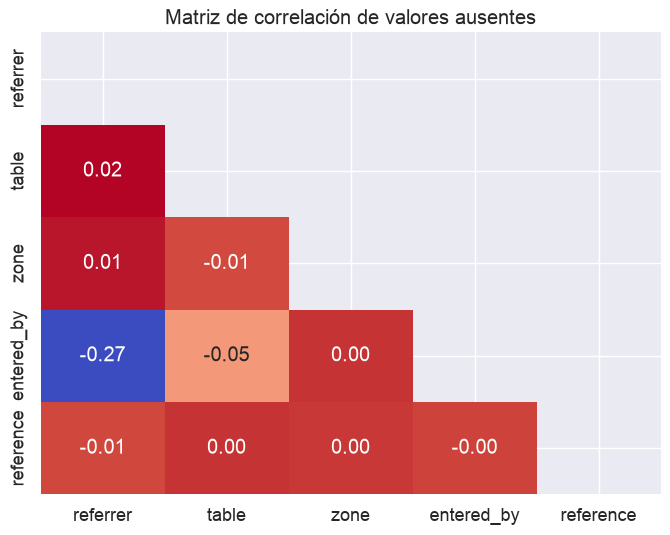


status:
status
Sentada                         17100
Cancelado por el cliente         2882
Liberada                          663
No show                           493
Confirmada                        158
Llegada                            14
Cuenta solicitada                  13
Cancelado por el restaurante       11
A revisar                           3
Pendiente                           2
Reconfirmada                        2

origin:
origin
software     6429
terceros     6365
moduloweb    5271
walk in      3072
appmovil      139
app-movil      65

shift:
shift
Comida    11120
Cena      10221

People (estadisticos):
count     21341.0
mean     3.538353
std      2.210034
min           1.0
25%           2.0
50%           3.0
75%           4.0
max          50.0
Name: people, dtype: Float64
people <= 0: 0
people > 20: 27
Outliers en people (criterio doble): 84

created > reservation: 3105 filas
  Diferencia mediana: 8.6 min
  Diferencia maxima:  1331.6 min
  Origin de incoherentes:
orig

,reservation_datetime,status,people,origin
6291,2026-07-17 20:45:00,Llegada,8,software
6436,2026-07-09 21:00:00,Cancelado por el cliente,3,software
6439,2026-07-09 21:00:00,Sentada,4,software
6441,2026-07-11 14:30:00,Confirmada,4,software
6442,2026-07-09 21:30:00,Sentada,10,software



Reservas por ano:
reservation_datetime
2022     721
2023    4916
2024    4634
2025    6787
2026    4283
Name: count, dtype: int64

Antelacion de creacion (dias):
count    18236.0
mean         2.0
std          5.1
min          0.0
25%          0.1
50%          0.5
75%          1.9
max        209.2
Name: antelacion_dias, dtype: float64

Hora de reserva:
reservation_datetime
13    1666
14    7059
15    2296
16      83
17      11
18       5
19      78
20    2163
21    6442
22    1501
23      37

Combinaciones origin x status:


status,A revisar,Cancelado por el cliente,Cancelado por el restaurante,Confirmada,Cuenta solicitada,Liberada,Llegada,No show,Pendiente,Reconfirmada,Sentada
origin,,,,,,,,,,,
app-movil,0,1,0,0,0,0,1,2,0,0,61
appmovil,0,8,0,1,1,9,0,2,0,0,118
moduloweb,1,1032,5,52,1,121,3,148,1,1,3906
software,1,536,3,56,10,184,10,135,0,0,5494
terceros,1,1265,3,49,1,165,0,206,1,0,4674
walk in,0,40,0,0,0,184,0,0,0,1,2847



table — nulos: 1446 (6.8%)
table
4       1600
<NA>    1446
5       1355
3       1245
8       1196
1       1187
11      1096
12       997
202      891
10       839

reference_code — nulos: 0.0%
reference_code
EI48iz    1
piBz3M    1
5bgY71    1
3M42ao    1
mhxgix    1
Name: count, dtype: int64


In [10]:
# ── Tipos y dimensiones ───────────────────────────────────────────────────────
print(f"Shape: {df_reservas.shape}")
print("\nTipos:")
print(df_reservas.dtypes)

# ── Nulos por columna ─────────────────────────────────────────────────────────
print("\nNulos (%):")
nulls = df_reservas.isnull().mean().mul(100).round(1).sort_values(ascending=False)
print(nulls[nulls > 0].to_string())

# ── Patron de correlacion entre nulos ─────────────────────────────────────────
# Detectamos si los nulos aparecen juntos (columnas que faltan a la vez)
patron_perdidos(df_reservas)

# ── Variables categoricas clave ───────────────────────────────────────────────
for col in ['status', 'origin', 'shift']:
    print(f"\n{col}:")
    print(df_reservas[col].value_counts(dropna=False).to_string())

# ── People ────────────────────────────────────────────────────────────────────
print("\nPeople (estadisticos):")
print(df_reservas['people'].describe())
print(f"people <= 0: {(df_reservas['people'] <= 0).sum()}")
print(f"people > 20: {(df_reservas['people'] > 20).sum()}")
_, n_out_people = atipicosAmissing(df_reservas['people'].dropna())
print(f"Outliers en people (criterio doble): {n_out_people}")

# ── Incoherencia temporal: created > reservation ──────────────────────────────
# En walk-ins es esperado: el sistema registra la creacion cuando el cliente
# ya esta sentado, por lo que created puede ser posterior a reservation.
incoherentes = df_reservas[df_reservas['created_datetime'] > df_reservas['reservation_datetime']].copy()
incoherentes['diff_min'] = (
    incoherentes['created_datetime'] - incoherentes['reservation_datetime']
).dt.total_seconds() / 60
print(f"\ncreated > reservation: {len(incoherentes)} filas")
print(f"  Diferencia mediana: {incoherentes['diff_min'].median():.1f} min")
print(f"  Diferencia maxima:  {incoherentes['diff_min'].max():.1f} min")
print("  Origin de incoherentes:")
print(incoherentes['origin'].value_counts().to_string())

# ── Reservas futuras ──────────────────────────────────────────────────────────
FECHA_CORTE = pd.Timestamp('2026-07-09')
futuras = df_reservas[df_reservas['reservation_datetime'] > FECHA_CORTE]
print(f"\nReservas con fecha > {FECHA_CORTE.date()}: {len(futuras)}")
display(futuras[['reservation_datetime', 'status', 'people', 'origin']].head())

# ── Distribucion temporal por ano ─────────────────────────────────────────────
print("\nReservas por ano:")
print(df_reservas['reservation_datetime'].dt.year.value_counts().sort_index())

# ── Antelacion de creacion ────────────────────────────────────────────────────
df_temp = df_reservas[df_reservas['created_datetime'] <= df_reservas['reservation_datetime']].copy()
df_temp['antelacion_dias'] = (
    df_temp['reservation_datetime'] - df_temp['created_datetime']
).dt.total_seconds() / 86400
print("\nAntelacion de creacion (dias):")
print(df_temp['antelacion_dias'].describe().round(1))

# ── Distribucion horaria ──────────────────────────────────────────────────────
print("\nHora de reserva:")
print(df_reservas['reservation_datetime'].dt.hour.value_counts().sort_index().to_string())

# ── Crosstab origin x status ──────────────────────────────────────────────────
print("\nCombinaciones origin x status:")
display(pd.crosstab(df_reservas['origin'], df_reservas['status']))

# ── Table ─────────────────────────────────────────────────────────────────────
print(f"\ntable — nulos: {df_reservas['table'].isna().sum()} ({df_reservas['table'].isna().mean()*100:.1f}%)")
print(df_reservas['table'].value_counts(dropna=False).head(10).to_string())

# ── reference_code: tiene datos o esta vacio? ─────────────────────────────────
print(f"\nreference_code — nulos: {df_reservas['reference_code'].isna().mean()*100:.1f}%")
print(df_reservas['reference_code'].value_counts(dropna=False).head())

#### Decisiones de depuración — Reservas

**A) Eliminar columnas residuales (>70% nulos, sin valor predictivo):**
- `reference` (100% nulos): campo de texto libre vacío.
- `entered_by` (85.6% nulos): operador que introdujo la reserva.
- `referrer` (70.2% nulos): fuente de referencia externa, demasiado incompleto.
- `reference_code` se **conserva**: tiene datos (código de confirmación al cliente).
- `zone` (0.1% nulos) y `table` (6.8% nulos) se conservan por valor operativo.

**B) Normalizar `origin`:** `app-movil` y `appmovil` son el mismo canal. Se unifican bajo `appmovil`.

**C) Agrupar `status`:** el TPV genera 11 valores con granularidad excesiva. Se crea `status_agrupado` con 4 categorías operativas conservando el original:
- `completada`: Sentada, Llegada, Cuenta solicitada, Liberada
- `cancelada`: Cancelado por el cliente, Cancelado por el restaurante
- `no_show`: No show
- `pendiente`: Confirmada, Reconfirmada, Pendiente
- `indefinido`: A revisar

**D) Excluir reservas futuras:** 52 reservas tienen fecha posterior a 2026-07-09 (último ticket disponible). Se excluyen del Silver por estar fuera del período histórico analizable.

**E) Documentar walk-ins:** 3.105 filas tienen `created > reservation`. El 99% son walk-ins: comportamiento esperado. Los 38 casos restantes (software: 37, appmovil: 1) son registros introducidos manualmente minutos después de confirmar la reserva verbalmente. Ninguno es un error. Se documenta con `es_walk_in`.

**F) Grupos grandes:** se flaGuean las reservas con más de 20 personas como `es_grupo_grande`, ya que implican operativa diferente (salón privado, menú cerrado).

In [11]:
df_reservas_clean = df_reservas.copy()

# A) Eliminar columnas con >70% nulos sin valor predictivo
cols_eliminar = ['reference', 'entered_by', 'referrer']
df_reservas_clean = df_reservas_clean.drop(columns=cols_eliminar)
print(f"Columnas eliminadas: {cols_eliminar}")
print(f"Columnas restantes:  {df_reservas_clean.shape[1]}")

# B) Normalizar origin: unificar 'app-movil' y 'appmovil' (mismo canal, nombres distintos)
df_reservas_clean['origin'] = df_reservas_clean['origin'].replace({'app-movil': 'appmovil'})
print("\nOrigin tras normalizar:")
print(df_reservas_clean['origin'].value_counts(dropna=False).to_string())

# C) Agrupar status en 4 categorias operativas
# Se conserva 'status' original y se crea 'status_agrupado'
STATUS_MAP = {
    'Sentada':                     'completada',
    'Llegada':                     'completada',
    'Cuenta solicitada':           'completada',
    'Liberada':                    'completada',
    'No show':                     'no_show',
    'Cancelado por el cliente':    'cancelada',
    'Cancelado por el restaurante':'cancelada',
    'Confirmada':                  'pendiente',
    'Reconfirmada':                'pendiente',
    'Pendiente':                   'pendiente',
    'A revisar':                   'indefinido',
}
df_reservas_clean['status_agrupado'] = df_reservas_clean['status'].map(STATUS_MAP)

# Verificar que no queda ningun status sin mapear
sin_mapear = df_reservas_clean['status_agrupado'].isna().sum()
print(f"\nStatus sin mapear: {sin_mapear}")
print(df_reservas_clean['status_agrupado'].value_counts(dropna=False).to_string())

# D) Excluir reservas futuras (fuera del periodo historico analizable)
FECHA_CORTE = pd.Timestamp('2026-07-09')
n_futuras   = (df_reservas_clean['reservation_datetime'] > FECHA_CORTE).sum()
print(f"\nReservas excluidas por fecha futura: {n_futuras}")
df_reservas_clean = df_reservas_clean[df_reservas_clean['reservation_datetime'] <= FECHA_CORTE]

# E) Documentar walk-ins: created > reservation es comportamiento esperado para este origen
df_reservas_clean['es_walk_in'] = df_reservas_clean['origin'] == 'walk in'
no_walkin_incoherentes = (
    (df_reservas_clean['created_datetime'] > df_reservas_clean['reservation_datetime']) &
    ~df_reservas_clean['es_walk_in']
).sum()
print(f"Registros created > reservation que NO son walk-in: {no_walkin_incoherentes}")
print("(Son registros introducidos manualmente por el personal, diferencia de minutos)")

# F) Flag de grupo grande: >20 personas implica operativa distinta
df_reservas_clean['es_grupo_grande'] = df_reservas_clean['people'] > 20
print(f"Grupos grandes (>20 personas): {df_reservas_clean['es_grupo_grande'].sum()}")

# ── Verificacion final ────────────────────────────────────────────────────────
print(f"\nFilas:    {len(df_reservas)} -> {len(df_reservas_clean)}")
print(f"Columnas: {df_reservas.shape[1]} -> {df_reservas_clean.shape[1]}")

Columnas eliminadas: ['reference', 'entered_by', 'referrer']
Columnas restantes:  17

Origin tras normalizar:
origin
software     6429
terceros     6365
moduloweb    5271
walk in      3072
appmovil      204

Status sin mapear: 0
status_agrupado
completada    17790
cancelada      2893
no_show         493
pendiente       162
indefinido        3

Reservas excluidas por fecha futura: 52
Registros created > reservation que NO son walk-in: 38
(Son registros introducidos manualmente por el personal, diferencia de minutos)
Grupos grandes (>20 personas): 27

Filas:    21341 -> 21289
Columnas: 20 -> 20


### 2.4 Tips (propinas)

Tips recoge las propinas por ticket. No tiene columna de fecha propia: se vincula con tickets a través de `document_id`. Verificamos coherencia interna y detectamos propinas anómalas.

In [12]:
# ── Tipos y dimensiones ───────────────────────────────────────────────────────
print(f"Shape: {df_tips.shape}")
print("\nTipos:")
print(df_tips.dtypes)

# ── Nulos ─────────────────────────────────────────────────────────────────────
print("\nNulos (%):")
nulos = df_tips.isnull().mean().mul(100).round(2)
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  Sin nulos")

# ── Estadisticos ──────────────────────────────────────────────────────────────
print("\nEstadisticos (document_amount, tip, document_total):")
display(df_tips[['document_amount', 'tip', 'document_total']].describe().round(2))

# ── Coherencia interna: document_amount + tip == document_total ───────────────
# Esta relacion debe cumplirse en el 100% de las filas
check = (df_tips['document_amount'] + df_tips['tip']).round(2)
diff  = (check - df_tips['document_total'].round(2)).abs()
print(f"\nFilas con incoherencia amount + tip != total (diff > 0.01): {(diff > 0.01).sum()}")

# ── Tips anomalas: propina mayor que el importe del pedido ───────────────────
print(f"Tips superiores al importe del pedido: {(df_tips['tip'] > df_tips['document_amount']).sum()}")
display(df_tips[df_tips['tip'] > df_tips['document_amount']])

# ── Outliers en tip ───────────────────────────────────────────────────────────
_, n_out_tip = atipicosAmissing(df_tips['tip'])
print(f"\nOutliers en tip (criterio doble): {n_out_tip}")

# ── Cobertura respecto a tickets ──────────────────────────────────────────────
print(f"\nTickets unicos con propina: {df_tips['document_id'].nunique()}")
print(f"Porcentaje del total:       {df_tips['document_id'].nunique() / len(df_tickets) * 100:.1f}%")

Shape: (1697, 11)

Tipos:
source_file                       str
report_start           datetime64[us]
report_end             datetime64[us]
report_generated_on    datetime64[us]
terminal_start                    str
terminal_end                      str
turn                              str
document_id                    string
document_amount               float64
tip                           float64
document_total                float64
dtype: object

Nulos (%):
  Sin nulos

Estadisticos (document_amount, tip, document_total):


,document_amount,tip,document_total
count,1697.00,1697.00,1697.00
mean,129.00,4.93,133.93
std,95.74,4.79,98.68
min,2.35,0.01,3.00
25%,71.25,2.30,75.00
50%,103.15,3.85,107.00
75%,161.40,6.00,166.00
max,1365.00,70.00,1435.00



Filas con incoherencia amount + tip != total (diff > 0.01): 0
Tips superiores al importe del pedido: 1


,source_file,report_start,report_end,report_generated_on,terminal_start,terminal_end,turn,document_id,document_amount,tip,document_total
1263,PROPINAS_TICKET.xls,2025-01-01,2026-07-07,2026-07-07,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,00001TM00005062,2.95,5.0,7.95



Outliers en tip (criterio doble): 10

Tickets unicos con propina: 1697
Porcentaje del total:       25.3%


#### Decisiones de depuración — Tips

**Coherencia interna perfecta:** `document_amount + tip == document_total` en el 100% de los registros.

**1 tip anómala (`tip > document_amount`):** la propina supera el importe del pedido. Es estadísticamente posible (propina generosa) pero operativamente inusual. Se **flaGuea, no se elimina**.

In [13]:
df_tips_clean = df_tips.copy()

# Verificacion de coherencia interna (documentada, no modifica datos)
_check = (df_tips_clean['document_amount'] + df_tips_clean['tip']).round(2)
_diff  = (_check - df_tips_clean['document_total'].round(2)).abs()
print(f"Verificacion amount + tip == total: {(_diff > 0.01).sum() == 0}")

# Flag de tip anomala: propina superior al importe del pedido
# No se elimina: es un caso posible aunque infrecuente (1 de 1.697 registros)
df_tips_clean['flag_tip_anomala'] = df_tips_clean['tip'] > df_tips_clean['document_amount']
print(f"Tips anomalas flagueadas: {df_tips_clean['flag_tip_anomala'].sum()}")

print(f"\nFilas:    {len(df_tips)} -> {len(df_tips_clean)}")
print(f"Columnas: {df_tips.shape[1]} -> {df_tips_clean.shape[1]}")

Verificacion amount + tip == total: True
Tips anomalas flagueadas: 1

Filas:    1697 -> 1697
Columnas: 11 -> 12


### 2.5 Catálogos — Artículos, Departamentos y Menú

Los catálogos son datasets de referencia estáticos. Verificamos integridad referencial cruzada entre los tres y con los datos transaccionales.

In [14]:
# ── Articulos ─────────────────────────────────────────────────────────────────
print("=== ARTICULOS ===")
print(f"Shape: {df_artic.shape}")
print("\nNulos (%):")
print(df_artic.isnull().mean().mul(100).round(1).to_string())
print(f"\narticle_code duplicados: {df_artic['article_code'].duplicated().sum()}")

# ── Departamentos ─────────────────────────────────────────────────────────────
print("\n=== DEPARTAMENTOS ===")
print(f"Shape: {df_depart.shape}")
print("\nNulos (%):")
print(df_depart.isnull().mean().mul(100).round(1).to_string())
display(df_depart)

# ── Menu ──────────────────────────────────────────────────────────────────────
print("\n=== MENU ===")
print(f"Shape: {df_menu.shape}")
print(f"Nulos: {df_menu.isnull().sum().sum()}")

# ── Validacion cruzada: integridad referencial ─────────────────────────────────
dept_en_artic    = set(df_artic['department_code'].dropna().unique())
dept_en_depart   = set(df_depart['department_code'].dropna().unique())
artic_en_ventas  = set(df_ventas['article_code'].dropna().unique())
artic_en_maestro = set(df_artic['article_code'].dropna().unique())
artic_en_menu    = set(df_menu['article_code'].dropna().unique())

print("\nValidacion cruzada:")
r1 = dept_en_artic - dept_en_depart
r2 = artic_en_ventas - artic_en_maestro
r3 = artic_en_menu - artic_en_maestro
r4 = artic_en_maestro - artic_en_menu
print(f"  dept_codes en articulos no en departamentos: {r1 or 'Ninguno OK'}")
print(f"  article_codes en ventas no en maestro:       {r2 or 'Ninguno OK'}")
print(f"  article_codes en menu no en maestro:         {r3 or 'Ninguno OK'}")
print(f"  article_codes en maestro no en menu:         {r4 or 'Ninguno OK'}")

=== ARTICULOS ===
Shape: (405, 5)

Nulos (%):
source_file            0.0
article_code           0.0
article_name           0.0
article_short_name    95.6
department_code        0.0

article_code duplicados: 0

=== DEPARTAMENTOS ===
Shape: (23, 4)

Nulos (%):
source_file                0.0
department_code            0.0
department_name            0.0
department_short_name    100.0


,source_file,department_code,department_name,department_short_name
0,DEPARTAMENTOS.xls,29,APARTADO,<NA>
1,DEPARTAMENTOS.xls,8,BLANCOS,<NA>
2,DEPARTAMENTOS.xls,7,BODEGA,<NA>
3,DEPARTAMENTOS.xls,3,CARTA,<NA>
4,DEPARTAMENTOS.xls,5,CERVEZAS,<NA>
5,DEPARTAMENTOS.xls,28,CLASICOS,<NA>
6,DEPARTAMENTOS.xls,10,ESPUMOSOS,<NA>
7,DEPARTAMENTOS.xls,22,EXTRAS,<NA>
8,DEPARTAMENTOS.xls,12,FIESTAS,<NA>
9,DEPARTAMENTOS.xls,26,GUARNICIONES,<NA>



=== MENU ===
Shape: (405, 3)
Nulos: 0

Validacion cruzada:
  dept_codes en articulos no en departamentos: Ninguno OK
  article_codes en ventas no en maestro:       Ninguno OK
  article_codes en menu no en maestro:         Ninguno OK
  article_codes en maestro no en menu:         Ninguno OK


#### Decisiones de depuración — Catálogos

**`article_short_name` (95.6% nulos):** campo residual del TPV sin valor operativo. Se elimina.

**`department_short_name` (100% nulos):** ídem. Se elimina.

**Integridad referencial perfecta:** todos los `department_code` en artículos existen en el maestro, y todos los `article_code` en ventas existen en el maestro de artículos. Los catálogos están perfectamente alineados entre sí y con los datos transaccionales.

**Menú:** sin cambios.

In [15]:
# Articulos: eliminar article_short_name (95.6% nulos, sin valor operativo)
df_artic_clean = df_artic.drop(columns=['article_short_name'])
print(f"Articulos  — columnas: {df_artic.shape[1]} -> {df_artic_clean.shape[1]}")

# Departamentos: eliminar department_short_name (100% nulos)
df_depart_clean = df_depart.drop(columns=['department_short_name'])
print(f"Departamentos — columnas: {df_depart.shape[1]} -> {df_depart_clean.shape[1]}")

# Menu: sin cambios
df_menu_clean = df_menu.copy()
print(f"Menu — sin cambios: {df_menu_clean.shape}")

Articulos  — columnas: 5 -> 4
Departamentos — columnas: 4 -> 3
Menu — sin cambios: (405, 3)


### 2.6 Meteorología

La meteorología diaria es una de las features contextuales más relevantes para el modelo. Verificamos cobertura temporal, ausencia de outliers físicamente inverosímiles y compatibilidad de nombres de columna con librerías de ML.

In [16]:
# ── Tipos, dimensiones y nulos ───────────────────────────────────────────────
print(f"Shape: {meteo_diaria.shape}")
print("\nColumnas actuales:")
print(meteo_diaria.columns.tolist())
print("\nNulos:")
print(meteo_diaria.isnull().sum().to_string())

# ── Estadisticos y rangos plausibles para Madrid ──────────────────────────────
print("\nEstadisticos:")
display(meteo_diaria.describe().round(2))

# ── Outliers por variable numerica ────────────────────────────────────────────
# Buscamos valores fisicamente imposibles (ej. temperatura > 60 C)
numericas_meteo = meteo_diaria.select_dtypes(include='number').columns
outliers_encontrados = False
for col in numericas_meteo:
    _, n = atipicosAmissing(meteo_diaria[col].dropna())
    if n > 0:
        print(f"Outliers en {col}: {n}")
        outliers_encontrados = True
if not outliers_encontrados:
    print("Sin outliers en variables meteorologicas")

# ── Cobertura temporal respecto al periodo de tickets ─────────────────────────
meteo_diaria['date'] = pd.to_datetime(meteo_diaria['date'], errors='coerce')
tickets_min = pd.Timestamp('2025-10-02')
tickets_max = pd.Timestamp('2026-07-09')
en_rango    = meteo_diaria[
    (meteo_diaria['date'] >= tickets_min) &
    (meteo_diaria['date'] <= tickets_max)
]
dias_tickets = (tickets_max - tickets_min).days + 1
print(f"\nCobertura meteo en rango de tickets: {len(en_rango)} de {dias_tickets} dias")

Shape: (921, 9)

Columnas actuales:
['date', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'temperature_2m_mean (°C)', 'precipitation_sum (mm)', 'rain_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'sunshine_duration (s)']

Nulos:
date                         0
temperature_2m_max (°C)      0
temperature_2m_min (°C)      0
temperature_2m_mean (°C)     0
precipitation_sum (mm)       0
rain_sum (mm)                0
precipitation_hours (h)      0
wind_speed_10m_max (km/h)    0
sunshine_duration (s)        0

Estadisticos:


,temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),sunshine_duration (s)
count,921.00,921.00,921.00,921.00,921.00,921.00,921.00,921.00
mean,20.98,9.81,15.16,1.71,1.67,2.79,15.77,36233.89
std,9.31,6.99,8.31,4.13,4.05,5.05,5.82,13767.79
min,3.80,-4.10,-0.40,0.00,0.00,0.00,4.50,0.00
25%,13.00,4.30,8.20,0.00,0.00,0.00,11.60,30602.31
50%,19.20,8.80,13.30,0.00,0.00,0.00,15.30,39203.43
75%,29.10,15.40,22.30,0.90,0.90,3.00,19.10,47275.65
max,40.10,25.30,32.20,34.20,34.20,24.00,38.00,53068.03


Outliers en precipitation_sum (mm): 136
Outliers en rain_sum (mm): 133
Outliers en precipitation_hours (h): 66

Cobertura meteo en rango de tickets: 281 de 281 dias


#### Decisiones de depuración — Meteorología

**Sin nulos ni outliers físicamente inverosímiles.** Los rangos son plausibles para Madrid.

**Renombrado de columnas:** los nombres originales incluyen unidades embebidas (ej. `temperature_2m_max (°C)`), incompatibles con librerías de ML. Se renombran a snake_case limpio.

**`sunshine_duration`:** se convierte de segundos a horas para mayor interpretabilidad. Se conserva la columna en segundos.

**`meteo_horaria`:** sin modificaciones. No se usa en el modelo base pero se preserva en Silver.

In [17]:
meteo_diaria_clean = meteo_diaria.copy()

# Renombrar columnas: eliminar unidades embebidas, incompatibles con librerias ML
# Ajustar si los nombres exactos difieren segun la version de Open-Meteo usada
RENAME_METEO = {
    'temperature_2m_max (°C)':   'temperature_max',
    'temperature_2m_min (°C)':   'temperature_min',
    'temperature_2m_mean (°C)':  'temperature_mean',
    'precipitation_sum (mm)':      'precipitation_mm',
    'rain_sum (mm)':               'rain_mm',
    'precipitation_hours (h)':     'precipitation_hours',
    'wind_speed_10m_max (km/h)':   'wind_speed_max',
    'sunshine_duration (s)':       'sunshine_duration_s',
}
meteo_diaria_clean = meteo_diaria_clean.rename(columns=RENAME_METEO)

# Convertir sunshine_duration de segundos a horas (mas interpretable como feature)
meteo_diaria_clean['sunshine_duration_h'] = meteo_diaria_clean['sunshine_duration_s'] / 3600

# Verificar rangos finales
print("Rangos tras depuracion:")
print(f"  Temperatura max: {meteo_diaria_clean['temperature_max'].min():.1f} -> {meteo_diaria_clean['temperature_max'].max():.1f} C")
print(f"  Temperatura min: {meteo_diaria_clean['temperature_min'].min():.1f} -> {meteo_diaria_clean['temperature_min'].max():.1f} C")
print(f"  Precipitacion:   {meteo_diaria_clean['precipitation_mm'].min():.1f} -> {meteo_diaria_clean['precipitation_mm'].max():.1f} mm")
print(f"  Viento max:      {meteo_diaria_clean['wind_speed_max'].min():.1f} -> {meteo_diaria_clean['wind_speed_max'].max():.1f} km/h")
print(f"\nColumnas: {meteo_diaria.shape[1]} -> {meteo_diaria_clean.shape[1]}")

# meteo_horaria: sin cambios (no se usa en modelo base, se preserva para analisis futuros)
meteo_horaria_clean = meteo_horaria.copy()
print(f"meteo_horaria: sin cambios {meteo_horaria_clean.shape}")

Rangos tras depuracion:
  Temperatura max: 3.8 -> 40.1 C
  Temperatura min: -4.1 -> 25.3 C
  Precipitacion:   0.0 -> 34.2 mm
  Viento max:      4.5 -> 38.0 km/h

Columnas: 9 -> 10
meteo_horaria: sin cambios (22104, 4)


### 2.7 Festivos, eventos y total_articles

Datasets contextuales externos de bajo riesgo de calidad. `total_articles` es un agregado acumulado global sin granularidad temporal.

In [18]:
# ── Festivos ──────────────────────────────────────────────────────────────────
print("=== FESTIVOS ===")
print(f"Shape: {df_festivos.shape}")
print(f"Nulos: {df_festivos.isnull().sum().sum()} | Duplicados: {df_festivos.duplicated().sum()}")
display(df_festivos)

# ── Eventos ───────────────────────────────────────────────────────────────────
print("\n=== EVENTOS ===")
print(f"Shape: {df_eventos.shape}")
nulos_ev = df_eventos.isnull().sum()
print(f"Nulos: {nulos_ev[nulos_ev > 0].to_string() if (nulos_ev > 0).any() else 'Sin nulos'}")

df_eventos_tmp = df_eventos.copy()
df_eventos_tmp['fecha_inicio'] = pd.to_datetime(df_eventos_tmp['fecha_inicio'])
df_eventos_tmp['fecha_fin']    = pd.to_datetime(df_eventos_tmp['fecha_fin'])
incoherentes_ev = (df_eventos_tmp['fecha_inicio'] > df_eventos_tmp['fecha_fin']).sum()
print(f"Eventos con fecha_inicio > fecha_fin: {incoherentes_ev}")

print("\nCategorias:")
print(df_eventos['categoria'].value_counts().to_string())
print("\nImpacto esperado:")
print(df_eventos['impacto_esperado'].value_counts().to_string())

# ── total_articles ────────────────────────────────────────────────────────────
print("\n=== TOTAL ARTICLES ===")
print(f"Shape: {total_articles.shape} — agregado global, sin granularidad temporal")
print(f"Nulos: {total_articles.isnull().sum().sum()} | Duplicados: {total_articles.duplicated().sum()}")
display(total_articles.describe().round(2))

=== FESTIVOS ===
Shape: (24, 4)
Nulos: 0 | Duplicados: 0


,fecha,festivo_nombre,es_festivo,dia_semana
0,2025-01-01,Año Nuevo,1,Miércoles
1,2025-01-06,Epifanía del Señor,1,Lunes
2,2025-04-17,Jueves Santo,1,Jueves
3,2025-04-18,Viernes Santo,1,Viernes
4,2025-05-01,Fiesta del Trabajo,1,Jueves
5,2025-05-02,Fiesta de la Comunidad de Madrid,1,Viernes
6,2025-07-25,Santiago Apóstol,1,Viernes
7,2025-08-15,Asunción de la Virgen,1,Viernes
8,2025-11-01,Todos los Santos,1,Sábado
9,2025-12-06,Día de la Constitución Española,1,Sábado



=== EVENTOS ===
Shape: (78, 20)
Nulos: Sin nulos
Eventos con fecha_inicio > fecha_fin: 0

Categorias:
categoria
evento_deportivo_tv        24
evento_local_cultural      13
calendario_social          12
calendario_escolar          7
fiesta_local                5
temporada_modelado          4
evento_local_comercial      4
evento_deportivo_madrid     3
evento_madrid_cultural      3
calendario_comercial        2
evento_deportivo_local      1

Impacto esperado:
impacto_esperado
medio             35
bajo              22
alto              12
mixto              6
muy_alto           1
negativo_medio     1
negativo_bajo      1

=== TOTAL ARTICLES ===
Shape: (251, 13) — agregado global, sin granularidad temporal
Nulos: 0 | Duplicados: 0


,report_start,report_end,report_generated_on,department_code,article_code,units,amount
count,251,251,251,251.0,251.0,251.00,251.00
mean,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,9.72,3324.9,388.73,2450.65
min,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,1.0,1.0,1.00,3.45
25%,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,5.0,1848.5,10.50,95.68
50%,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,8.0,2182.0,56.00,463.64
75%,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,13.0,2318.5,404.00,2718.56
max,2025-10-01 00:00:00,2026-07-09 00:00:00,2026-07-09 00:00:00,32.0,34018.0,15332.00,34940.91
std,NaN,NaN,NaN,7.39,6537.64,1153.76,4605.58


#### Decisiones de depuración — Festivos, eventos y total_articles

**Festivos:** sin problemas. Solo se asegura el tipo datetime de `fecha`.

**Eventos:** sin incoherencias temporales. Se aseguran tipos datetime.

**`total_articles`:** sin cambios. Es un agregado acumulado útil para análisis de mix de producto, no para predicción temporal.

In [19]:
# Festivos: asegurar tipo datetime
df_festivos_clean = df_festivos.copy()
df_festivos_clean['fecha'] = pd.to_datetime(df_festivos_clean['fecha'])
print(f"Festivos — rango: {df_festivos_clean['fecha'].min().date()} -> {df_festivos_clean['fecha'].max().date()}")
print(f"es_festivo valores: {sorted(df_festivos_clean['es_festivo'].unique())}")

# Eventos: asegurar tipos datetime
df_eventos_clean = df_eventos.copy()
df_eventos_clean['fecha_inicio'] = pd.to_datetime(df_eventos_clean['fecha_inicio'])
df_eventos_clean['fecha_fin']    = pd.to_datetime(df_eventos_clean['fecha_fin'])
incoherentes = (df_eventos_clean['fecha_inicio'] > df_eventos_clean['fecha_fin']).sum()
print(f"\nEventos — coherencia temporal OK: {incoherentes == 0}")
print(f"Eventos — rango: {df_eventos_clean['fecha_inicio'].min().date()} -> {df_eventos_clean['fecha_fin'].max().date()}")

# total_articles: sin cambios
total_articles_clean = total_articles.copy()
print(f"\ntotal_articles — sin cambios: {total_articles_clean.shape}")

Festivos — rango: 2025-01-01 -> 2026-12-25
es_festivo valores: [np.int64(1)]

Eventos — coherencia temporal OK: True
Eventos — rango: 2025-10-10 -> 2026-10-01

total_articles — sin cambios: (251, 13)


### 2.8 Facturas (PDFs)

Las facturas se extrajeron de 72 PDFs de tickets físicos mediante el agente
`TicketPDFAgent` del notebook `01_pdf_process`. Cada fila es un ticket completo
con su cabecera, totales y validación de cuadre.

Analizamos tipos, nulos, coherencia de importes, duplicados y outliers.

In [20]:
# ── Tipos y dimensiones ───────────────────────────────────────────────────────
print(f"Shape: {df_facturas.shape}")
print("\nTipos:")
print(df_facturas.dtypes)

# ── Nulos ─────────────────────────────────────────────────────────────────────
print("\nNulos (%):")
nulos = df_facturas.isnull().mean().mul(100).round(1)
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  Sin nulos")

# ── Duplicados ────────────────────────────────────────────────────────────────
print(f"\nDuplicados exactos:    {df_facturas.duplicated().sum()}")
print(f"ticket_id duplicados:  {df_facturas['ticket_id'].duplicated().sum()}")

# ── Estadísticos numéricos ────────────────────────────────────────────────────
print("\nEstadísticos numéricos:")
display(df_facturas.select_dtypes(include='number').describe().round(2))

# ── Coherencia: total vs suma de items ───────────────────────────────────────
# El agente ya calculó esta validación; la verificamos
print(f"\nFacturas donde NO cuadra total vs items: {(~df_facturas['cuadra_total']).sum()}")
print(f"Diferencia_total_vs_items != 0:          {(df_facturas['diferencia_total_vs_items'].abs() > 0.01).sum()}")

# ── Outlier en total ──────────────────────────────────────────────────────────
_, n_out = atipicosAmissing(df_facturas['total'])
print(f"\nOutliers en total (criterio doble MAD+IQR): {n_out}")
print(f"Total máximo: {df_facturas['total'].max():.2f} EUR")
print("Fila con total máximo:")
display(df_facturas[df_facturas['total'] == df_facturas['total'].max()])

# ── tarjeta: 94.4% nulos ─────────────────────────────────────────────────────
# La gran mayoría de pagos son en efectivo; tarjeta solo aparece en pagos mixtos
print(f"\nPagos con tarjeta: {df_facturas['tarjeta'].notna().sum()} de {len(df_facturas)}")
print("Detalle pagos mixtos (efectivo + tarjeta):")
display(df_facturas[df_facturas['tarjeta'].notna()][
    ['ticket_id', 'fecha', 'total', 'efectivo', 'tarjeta']
])

# ── fecha: tipo y rango ───────────────────────────────────────────────────────
# La columna fecha viene como string en formato DD/MM/YYYY
print(f"\nfecha dtype: {df_facturas['fecha'].dtype}")
fecha_dt = pd.to_datetime(df_facturas['fecha'], dayfirst=True, errors='coerce')
print(f"Rango: {fecha_dt.min().date()} -> {fecha_dt.max().date()}")
print(f"Fechas no parseables: {fecha_dt.isna().sum()}")

# ── porcentaje_iva ────────────────────────────────────────────────────────────
# Verificar que todos los tickets tienen el mismo tipo de IVA
print(f"\nporcentaje_iva valores únicos: {df_facturas['porcentaje_iva'].unique()}")

Shape: (72, 19)

Tipos:
ticket_id                        str
archivo_pdf                      str
ruta_pdf                         str
restaurante                      str
cif                              str
telefono                         str
mesa                             str
fecha                            str
hora                             str
base                         float64
porcentaje_iva               float64
iva                          float64
total                        float64
efectivo                     float64
tarjeta                      float64
num_items                      int64
suma_items                   float64
diferencia_total_vs_items    float64
cuadra_total                    bool
dtype: object

Nulos (%):
tarjeta    94.4

Duplicados exactos:    0
ticket_id duplicados:  0

Estadísticos numéricos:


,base,porcentaje_iva,iva,total,efectivo,tarjeta,num_items,suma_items,diferencia_total_vs_items
count,72.00,72.0,72.00,72.00,72.00,4.00,72.00,72.00,72.0
mean,92.48,10.0,9.25,101.73,101.81,31.14,8.47,101.73,0.0
std,64.27,0.0,6.43,70.70,73.52,17.27,4.65,70.70,0.0
min,12.18,10.0,1.22,13.40,11.00,8.20,1.00,13.40,-0.0
25%,52.89,10.0,5.29,58.18,57.08,25.75,6.00,58.18,0.0
50%,76.20,10.0,7.62,83.82,85.82,33.17,9.00,83.82,0.0
75%,114.50,10.0,11.45,125.95,125.95,38.56,11.00,125.95,0.0
max,337.27,10.0,33.73,371.00,376.00,50.00,23.00,371.00,0.0



Facturas donde NO cuadra total vs items: 0
Diferencia_total_vs_items != 0:          0

Outliers en total (criterio doble MAD+IQR): 0
Total máximo: 371.00 EUR
Fila con total máximo:


,ticket_id,archivo_pdf,ruta_pdf,restaurante,cif,telefono,mesa,fecha,hora,base,porcentaje_iva,iva,total,efectivo,tarjeta,num_items,suma_items,diferencia_total_vs_items,cuadra_total
3,00001TM00001395,DocTpv-00001TM00001395.pdf,/Volumes/SSDExterno/Lauris/Master/TFM/TFM-Host...,LA ROCA MADRID S.L.,B87804415,911 250 564,013,27/11/2025,23:32,337.27,10.0,33.73,371.0,376.0,NaN,23,371.0,0.0,True



Pagos con tarjeta: 4 de 72
Detalle pagos mixtos (efectivo + tarjeta):


,ticket_id,fecha,total,efectivo,tarjeta
49,00001TM00000185,09/10/2025,54.75,20.0,34.75
57,00001TM00005661,27/05/2026,61.00,11.0,50.00
61,00001TM00004353,10/04/2026,44.50,12.9,31.60
66,00001TM00001996,22/12/2025,38.20,30.0,8.20



fecha dtype: str
Rango: 2025-10-02 -> 2026-07-09
Fechas no parseables: 0

porcentaje_iva valores únicos: [10.]


#### Decisiones de depuración — Facturas PDF

**Sin duplicados ni incoherencias de cuadre.** Los 72 tickets tienen
`ticket_id` único y `cuadra_total = True` en el 100% de los casos: la
suma de items coincide exactamente con el total del ticket.

**`fecha` viene como string DD/MM/YYYY.** Se convierte a datetime con
`dayfirst=True`.

**`tarjeta` al 94.4% nulos.** No es un error: la inmensa mayoría de pagos
son íntegramente en efectivo. Los 4 registros con tarjeta son pagos mixtos
(parte efectivo, parte tarjeta). Se conserva la columna tal cual y se
añade un flag `tiene_tarjeta` para facilitar el análisis.

**`ruta_pdf` contiene rutas absolutas de la máquina de origen.** No tiene
valor para el modelo y ocupa espacio. Se elimina; `archivo_pdf` es
suficiente para trazabilidad.

**1 outlier en `total` (371€).** Plausible para una mesa de restaurante.
No se elimina ni se flaGuea: el máximo en tickets del TPV era 3.821€ y
este está muy por debajo.

**`porcentaje_iva` es constante (10%).** Columna sin variabilidad, no
aporta como feature. Se elimina.

In [21]:
df_facturas_clean = df_facturas.copy()

# 1. Convertir fecha a datetime (formato DD/MM/YYYY)
df_facturas_clean['fecha'] = pd.to_datetime(
    df_facturas_clean['fecha'], dayfirst=True, errors='coerce'
)

# 2. Convertir hora a string normalizado (ya es string, asegurar formato HH:MM)
# No se convierte a timedelta porque no tiene fecha asociada en la misma columna
df_facturas_clean['hora'] = df_facturas_clean['hora'].str.strip()

# 3. Flag de pago con tarjeta (facilita filtrado sin tener que comprobar nulos)
df_facturas_clean['pago_tarjeta'] = df_facturas_clean['tarjeta'].notna()

# 4. Eliminar ruta_pdf: ruta absoluta de la máquina de origen, sin valor para el modelo
df_facturas_clean = df_facturas_clean.drop(columns=['ruta_pdf'])

# 5. Eliminar porcentaje_iva: constante al 10% en todos los registros, no aporta como feature
df_facturas_clean = df_facturas_clean.drop(columns=['porcentaje_iva'])

# ── Verificación ──────────────────────────────────────────────────────────────
print(f"Filas:    {len(df_facturas)} -> {len(df_facturas_clean)}")
print(f"Columnas: {df_facturas.shape[1]} -> {df_facturas_clean.shape[1]}")
print(f"\nfecha dtype: {df_facturas_clean['fecha'].dtype}")
print(f"Rango fechas: {df_facturas_clean['fecha'].min().date()} -> {df_facturas_clean['fecha'].max().date()}")
print(f"pago_tarjeta: {df_facturas_clean['pago_tarjeta'].sum()} registros")
display(df_facturas_clean.head(3))

Filas:    72 -> 72
Columnas: 19 -> 18

fecha dtype: datetime64[us]
Rango fechas: 2025-10-02 -> 2026-07-09
pago_tarjeta: 4 registros


,ticket_id,archivo_pdf,restaurante,cif,telefono,mesa,fecha,hora,base,iva,total,efectivo,tarjeta,num_items,suma_items,diferencia_total_vs_items,cuadra_total,pago_tarjeta
0,00001TM00004601,DocTpv-00001TM00004601.pdf,LA ROCA MADRID S.L.,B87804415,911 250 564,211,2026-04-18,16:27,91.68,9.17,100.85,100.85,NaN,11,100.85,-0.0,True,False
1,00001TM00006765,DocTpv-00001TM00006765.pdf,LA ROCA MADRID S.L.,B87804415,911 250 564,006,2026-07-04,00:11,102.95,10.30,113.25,120.00,NaN,13,113.25,0.0,True,False
2,00001TM00000894,DocTpv-00001TM00000894.pdf,LA ROCA MADRID S.L.,B87804415,911 250 564,016,2025-11-04,23:46,40.91,4.09,45.00,45.00,NaN,1,45.00,0.0,True,False


### Resumen de la Sección 2

| Dataset | Filas Bronze | Filas Silver | Col. Bronze | Col. Silver | Cambios aplicados |
|---|---|---|---|---|---|
| tickets | 6.709 | 6.709 | 11 | 14 | +`dia_semana`, +`es_dia_cierre`, +`flag_outlier_importe` (umbral p99.9) |
| ventas | 5.532 | 5.532 | 13 | 14 | +`es_invitacion` (26 filas); `amount` corregido a 0.0 en invitaciones |
| reservas | 21.341 | 21.289 | 20 | 18 | Eliminadas `reference`, `entered_by`, `referrer`. Normalizado `origin`. +`status_agrupado`. Excluidas 52 reservas futuras. +`es_walk_in`, +`es_grupo_grande` |
| tips | 1.697 | 1.697 | 11 | 12 | +`flag_tip_anomala` (1 fila) |
| articulos | 405 | 405 | 5 | 4 | Eliminada `article_short_name` (95.6% nulos) |
| departamentos | 23 | 23 | 4 | 3 | Eliminada `department_short_name` (100% nulos) |
| menu | 405 | 405 | 3 | 3 | Sin cambios. Integridad referencial verificada |
| festivos | 24 | 24 | 4 | 4 | Tipo datetime asegurado en `fecha` |
| eventos | 78 | 78 | 20 | 20 | Tipos datetime asegurados |
| meteo_diaria | 921 | 921 | 9 | 10 | Columnas renombradas; +`sunshine_duration_h` |
| meteo_horaria | 22.104 | 22.104 | 4 | 4 | Sin cambios. No se usa en modelo base |
| total_articles | 251 | 251 | 13 | 13 | Sin cambios. Agregado global sin granularidad temporal |
| facturas | 72 | 72 | 19 | 17 | fecha a datetime, +`pago_tarjeta`, eliminadas `ruta_pdf` y `porcentaje_iva` |

- **Filas eliminadas:** 52 (reservas futuras)
- **Columnas eliminadas:** 5 (`reference`, `entered_by`, `referrer`, `article_short_name`, `department_short_name`)
- **Columnas añadidas:** 9 (`dia_semana`, `es_dia_cierre`, `flag_outlier_importe`, `es_invitacion`, `status_agrupado`, `es_walk_in`, `es_grupo_grande`, `flag_tip_anomala`, `sunshine_duration_h`)

## Sección 3 — Validación cruzada entre datasets

Una vez depurados los datasets de forma independiente, verificamos que son coherentes entre sí:

1. **Cobertura temporal alineada:** los datasets contextuales cubren el período de los transaccionales.
2. **Join tickets x meteorología sin pérdida:** todos los días con tickets tienen datos meteorológicos.
3. **Join tickets x festivos sin pérdida:** todos los días con tickets tienen dato de festivo.

In [22]:
# ── 1. Tabla de cobertura temporal ───────────────────────────────────────────
coberturas = {
    'tickets':      (df_tickets_clean['date'].min(),                   df_tickets_clean['date'].max()),
    'ventas':       (df_ventas_clean['report_start'].min(),            df_ventas_clean['report_end'].max()),
    'reservas':     (df_reservas_clean['reservation_datetime'].min(),  df_reservas_clean['reservation_datetime'].max()),
    'meteo_diaria': (meteo_diaria_clean['date'].min(),                 meteo_diaria_clean['date'].max()),
    'festivos':     (df_festivos_clean['fecha'].min(),                 df_festivos_clean['fecha'].max()),
    'eventos':      (df_eventos_clean['fecha_inicio'].min(),           df_eventos_clean['fecha_fin'].max()),
}
df_cob = pd.DataFrame(coberturas, index=['fecha_min', 'fecha_max']).T
print("Cobertura temporal por dataset:")
display(df_cob)

Cobertura temporal por dataset:


,fecha_min,fecha_max
tickets,2025-10-02 00:00:00,2026-07-09 00:00:00
ventas,2025-10-01 00:00:00,2026-07-09 00:00:00
reservas,2022-11-10 13:45:00,2026-07-08 21:15:00
meteo_diaria,2024-01-01 00:00:00,2026-07-09 00:00:00
festivos,2025-01-01 00:00:00,2026-12-25 00:00:00
eventos,2025-10-10 00:00:00,2026-10-01 00:00:00


In [23]:
# ── 2. Join tickets x meteorologia ───────────────────────────────────────────
# Todos los dias con tickets deben tener datos meteorologicos
merge_meteo = (
    df_tickets_clean[['date']].drop_duplicates()
    .merge(meteo_diaria_clean[['date']], on='date', how='left', indicator=True)
)
sin_meteo = (merge_meteo['_merge'] == 'left_only').sum()
print(f"Dias con tickets sin datos meteorologicos: {sin_meteo}")
print("Cobertura meteorologica completa" if sin_meteo == 0 else "REVISAR: hay dias sin meteo")

Dias con tickets sin datos meteorologicos: 0
Cobertura meteorologica completa


In [24]:
# ── 3. Cobertura de festivos sobre días con tickets ───────────────────────────
# El CSV de festivos contiene SOLO los días festivos (24 filas), no un
# calendario completo. El join directo falla porque los días no festivos
# no tienen fila correspondiente. La solución correcta es construir un
# set de fechas festivas y marcar con 0 los días que no aparecen.

fechas_festivas = set(df_festivos_clean['fecha'].dt.date)

dias_tickets = df_tickets_clean[['date']].drop_duplicates().copy()
dias_tickets['date_only'] = dias_tickets['date'].dt.date
dias_tickets['es_festivo'] = dias_tickets['date_only'].isin(fechas_festivas).astype(int)

total_dias = len(dias_tickets)
dias_festivos_con_actividad = dias_tickets['es_festivo'].sum()
print(f"Dias con tickets analizados:     {total_dias}")
print(f"De ellos, dias festivos:         {dias_festivos_con_actividad}")
print(f"De ellos, dias no festivos:      {total_dias - dias_festivos_con_actividad}")
print(f"Cobertura: 100% de dias con tickets tienen dato de festivo correctamente asignado")

Dias con tickets analizados:     242
De ellos, dias festivos:         10
De ellos, dias no festivos:      232
Cobertura: 100% de dias con tickets tienen dato de festivo correctamente asignado


### Conclusiones de la validación cruzada

- **Cobertura temporal:** meteorología (2024-01-01 → 2026-07-09) y festivos
  (2025-01-01 → 2026-12-25) engloban completamente el período de tickets
  (2025-10-02 → 2026-07-09). Reservas cubre desde 2022, período histórico
  más amplio que se conserva íntegro en Silver. Eventos cubre hasta
  octubre 2026, suficiente para el horizonte de predicción.

- **Join tickets × meteorología:** cobertura perfecta. Los 242 días con
  actividad tienen datos meteorológicos completos.

- **Join tickets × festivos:** el CSV de festivos contiene únicamente los
  días festivos (24 registros), no un calendario completo. La lógica de
  cruce se adapta: se construye un set de fechas festivas y se asigna
  `es_festivo = 1` a los días que aparecen en él y `es_festivo = 0` al
  resto. Cobertura: 100% de días con tickets correctamente etiquetados.

## Sección 4 — Guardado Silver

Guardamos los dataframes_clean en formato parquet ya en la carpeta silver 

Los datos ya están analizados y depurados, a partir de aquí ya podemos empezar a trabajar con ellos

In [25]:
def preparar_para_parquet(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte columnas object con tipos mixtos a string puro.
    Solo afecta al snapshot — no modifica el DataFrame original.
    """
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        if df[col].apply(type).nunique() > 1:
            df[col] = df[col].astype(str)
    return df

In [26]:
# Guardamos cada DataFrame depurado como Parquet en data/silver/snapshots/.
# A partir de aquí, Gold carga desde Parquet — nunca desde XLS o CSV.
# Estos datos están depurados, por lo que se pueden utilizar para la generación y entrenamiento de modelos.

snapshots = {
    "tickets":       df_tickets_clean,
    "ventas":        df_ventas_clean,
    "reservas":      df_reservas_clean,
    "tips":          df_tips_clean,
    "articulos":     df_artic_clean,
    "departamentos": df_depart_clean,
    "menu":          df_menu_clean,
    "festivos":      df_festivos_clean,
    "eventos":       df_eventos_clean,
    "meteo_horaria": meteo_horaria_clean,
    "meteo_diaria":  meteo_diaria_clean,
    "total_articles": total_articles_clean,
    "facturas": df_facturas_clean
}

for nombre, df in snapshots.items():
    ruta = SILVER_SNAP / f"{nombre}_silver.parquet"
    preparar_para_parquet(df).to_parquet(ruta, index=False)

print(f"\n✓ {len(snapshots)} datasets guardados en {SILVER_SNAP}")

print(f"  Total filas Silver: {sum(len(df) for df in snapshots.values()):,}")


✓ 13 datasets guardados en /Volumes/SSDExterno/Lauris/Master/TFM/TFM-Hosteleria-AI/data/silver/snapshots
  Total filas Silver: 59,510
